In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '/Users/evasmorodina/Work/ab_ag_champloo/data/structure_accuracy/'
train_test = '/Users/evasmorodina/Work/ab_ag_champloo/data/champloo_traintest_boltz2_chai1_af3_splits.csv'
image_path = '/Users/evasmorodina/Work/ab_ag_champloo/results/'

In [3]:
def make_split_dict(df, split_col, id_col="pdb_id"):
    return (df[[id_col, split_col]]
            .dropna()
            .drop_duplicates(subset=[id_col], keep="last")
            .set_index(id_col)[split_col]
            .to_dict())

def add_labels_from_id(
    df: pd.DataFrame,
    id_col="ID",
    split_map=None,
    unknown_label="unknown",
    out_name_col="name",
    out_type_col="type",
    out_split_col="split_label",
):
    """
    Vectorized replacement for:
      - df["name"] = ...
      - df["type"] = classify(...)
      - df["split_label"] = determine_split_label(...)

    Expected ID format (base): system_num1_num2_pdb1_pdb2[_model...]
    """
    if split_map is None:
        split_map = {}

    # --- base name (strip _model suffix) ---
    base = df[id_col].astype("string").str.split("_model", n=1).str[0]
    df[out_name_col] = base

    parts = base.str.split("_", expand=True)

    # Guard: ensure enough columns exist
    # we need indices 1,2,3,4
    needed = 5
    if parts.shape[1] < needed:
        # Create missing cols as NA to avoid IndexErrors
        for j in range(parts.shape[1], needed):
            parts[j] = pd.NA

    n1 = parts[1]
    n2 = parts[2]
    p1 = parts[3].str.upper()
    p2 = parts[4].str.upper()

    # --- type: "real" if num1==num2 and pdb1==pdb2 and we have enough parts ---
    # (matches your original classify() rule)
    has_fmt = parts[0].notna() & parts[1].notna() & parts[2].notna() & parts[3].notna() & parts[4].notna()
    is_real = has_fmt & (n1 == n2) & (p1 == p2)
    df[out_type_col] = np.where(is_real, "real", "shuffled")

    # --- split_label: map pdb1/pdb2 -> split membership, then decide ---
    # build mapping Series (upper-case keys)
    split_series = pd.Series(split_map)
    # if your split_map keys aren't guaranteed upper-case, normalize once:
    if len(split_series.index) and isinstance(split_series.index[0], str):
        split_series.index = split_series.index.str.upper()

    s1 = p1.map(split_series)
    s2 = p2.map(split_series)

    # unknown if can't parse OR one side unknown
    unknown_mask = (~has_fmt) | s1.isna() | s2.isna()

    both_mask = (s1.notna() & s2.notna() & (s1 != s2))
    same_mask = (s1.notna() & s2.notna() & (s1 == s2))

    out = np.full(len(df), unknown_label, dtype=object)
    out[same_mask.to_numpy()] = s1[same_mask].to_numpy()
    out[both_mask.to_numpy()] = "both"
    # unknown stays unknown
    df[out_split_col] = out

    return df

In [4]:
def plot_split_distribution_df(
    df,
    col="score",
    split_col="split_label",
    type_col="type",
    palette=None,
    kind="violin",                 # "violin" or "box"
    figsize=(10, 6),
    title=None,
    save_path=None,
    x_order=("train", "test", "both"),
    ylim=None,                     # e.g. (0, 1.05) or (0, 100)
    annotate=True,
    cut=0,                         # for violin
):
    if palette is None:
        palette = {'real': '#E2BC23', 'shuffled': '#937B2E'}

    d = df[[split_col, type_col, col]].dropna(subset=[split_col, type_col, col]).copy()

    # --- enforce x-axis order ---
    present = set(d[split_col].unique())
    x_levels = [x for x in x_order if x in present]
    if not x_levels:
        x_levels = list(d[split_col].unique())

    hue_levels_present = d[type_col].dropna().unique()

    fig, ax = plt.subplots(figsize=figsize)
    plot_func = sns.violinplot if kind == "violin" else sns.boxplot

    # --- draw plot ---
    if len(hue_levels_present) > 1:
        kwargs = dict(
            data=d,
            x=split_col,
            y=col,
            hue=type_col,
            palette=palette,
            order=x_levels,
            dodge=True,
            ax=ax,
        )
        if kind == "violin":
            kwargs.update(dict(cut=cut))
        plot_func(**kwargs)
    else:
        single_type = hue_levels_present[0]
        kwargs = dict(
            data=d[d[type_col] == single_type],
            x=split_col,
            y=col,
            order=x_levels,
            ax=ax,
            width=0.4 if kind == "box" else None,
            color=palette.get(single_type, "gray"),
        )
        if kind == "violin":
            kwargs.update(dict(cut=cut))
            # violinplot doesn't accept width like boxplot
            kwargs.pop("width", None)
        plot_func(**kwargs)

    # --- axis formatting ---
    ax.set_xlim(-0.5, len(x_levels) - 0.5)
    ax.set_title(title or col, fontsize=30)
    ax.set_xlabel("")
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    #ax.set_ylabel(col)
    ax.set_ylabel("clash score", fontsize=14)

    if ylim is not None:
        ax.set_ylim(*ylim)
    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin

    # --- remove axis legend (we’ll do global legend) ---
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

    # --- annotations (mean ± std) ---
    if annotate:
        stats = (
            d.groupby([split_col, type_col], observed=True)[col]
             .agg(['mean', 'std'])
             .reset_index()
        )

        hue_offset = 0.2 if len(hue_levels_present) > 1 else 0.0
        y_pos = ymax - 0.05 * y_range

        # stable hue ordering for offsets
        hue_order = list(hue_levels_present)

        for _, r in stats.iterrows():
            split_label = r[split_col]
            group_type  = r[type_col]
            mean, std   = r["mean"], r["std"]

            if split_label not in x_levels:
                continue

            x_idx = x_levels.index(split_label)

            if len(hue_levels_present) > 1:
                # left/right based on hue order
                xpos = x_idx - hue_offset if group_type == hue_order[0] else x_idx + hue_offset
            else:
                xpos = x_idx

            ax.text(
                xpos,
                y_pos,
                f"{mean:.2f}±{std:.2f}",
                ha="center",
                va="bottom",
                fontsize=13,
                color=palette.get(group_type, "black"),
            )

    # --- global legend ---
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=len(hue_levels_present),
            frameon=False,
            bbox_to_anchor=(0.5, -0.02),
            fontsize=25,
        )

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.subplots_adjust(bottom=0.15)

    if save_path:
        plt.savefig(save_path, dpi=500, bbox_inches="tight")

    return fig, ax

In [5]:
df_train_test = pd.read_csv(train_test)

boltz2_dict = make_split_dict(df_train_test, "boltz2_split")
chai1_dict  = make_split_dict(df_train_test, "chai1_split")
af3_dict    = make_split_dict(df_train_test, "alphafold3_split")

df_af3 = pd.read_csv(path + "topmodel_af3.csv")
df_chai1 = pd.read_csv(path + "topmodel_chai1.csv")
df_boltz2 = pd.read_csv(path + "topmodel_boltz2.csv")

df_af3 = add_labels_from_id(df_af3, id_col="ID", split_map=af3_dict)
df_chai1 = add_labels_from_id(df_chai1, id_col="ID", split_map=chai1_dict)
df_boltz2 = add_labels_from_id(df_boltz2, id_col="ID", split_map=boltz2_dict)

In [6]:
remove_ids = ['3EZJ', '7V9L', '8CI1', '8F8W', '8G0W', '8QZ3', '8Z8M', '9G1Y', '7XTP', '8B7W', '8FXV', '8IM0', '8RW9', '8WCG', '6ZE1', '8UVY']
pattern = '|'.join(remove_ids)

df_af3 = df_af3[~df_af3['ID'].str.contains(pattern, case=False, na=False)]
df_chai1 = df_chai1[~df_chai1['ID'].str.contains(pattern, case=False, na=False)]
df_boltz2 = df_boltz2[~df_boltz2['ID'].str.contains(pattern, case=False, na=False)]

In [7]:
df_af3.shape, df_chai1.shape, df_boltz2.shape

((556234, 5), (531728, 5), (561724, 5))

In [8]:
df_af3

,ID,score,name,type,split_label
0,system_100_101_8sos_8tw3_model_2.pdb.topmodel,42.0,system_100_101_8sos_8tw3,shuffled,test
1,system_100_39_8sos_7saj_model_32.pdb.topmodel,24.0,system_100_39_8sos_7saj,shuffled,test
2,system_101_113_8tw3_9emy_model_24.pdb.topmodel,28.0,system_101_113_8tw3_9emy,shuffled,test
3,system_101_77_8tw3_8h3x_model_21.pdb.topmodel,19.0,system_101_77_8tw3_8h3x,shuffled,test
4,system_15_19_6cwg_6k69_model_15.pdb.topmodel,19.0,system_15_19_6cwg_6k69,shuffled,train
...,...,...,...,...,...
723522,system_9_10_4x7c_4x7f_model_11.pdb.topmodel,14.0,system_9_10_4x7c_4x7f,shuffled,train
723523,system_99_94_8s0l_8q95_model_3.pdb.topmodel,32.0,system_99_94_8s0l_8q95,shuffled,test
723524,system_9_10_4x7c_4x7f_model_12.pdb.topmodel,14.0,system_9_10_4x7c_4x7f,shuffled,train
723525,system_99_94_8s0l_8q95_model_30.pdb.topmodel,33.0,system_99_94_8s0l_8q95,shuffled,test


In [9]:
palette = {'real': '#E2BC23', 'shuffled': '#937B2E'}

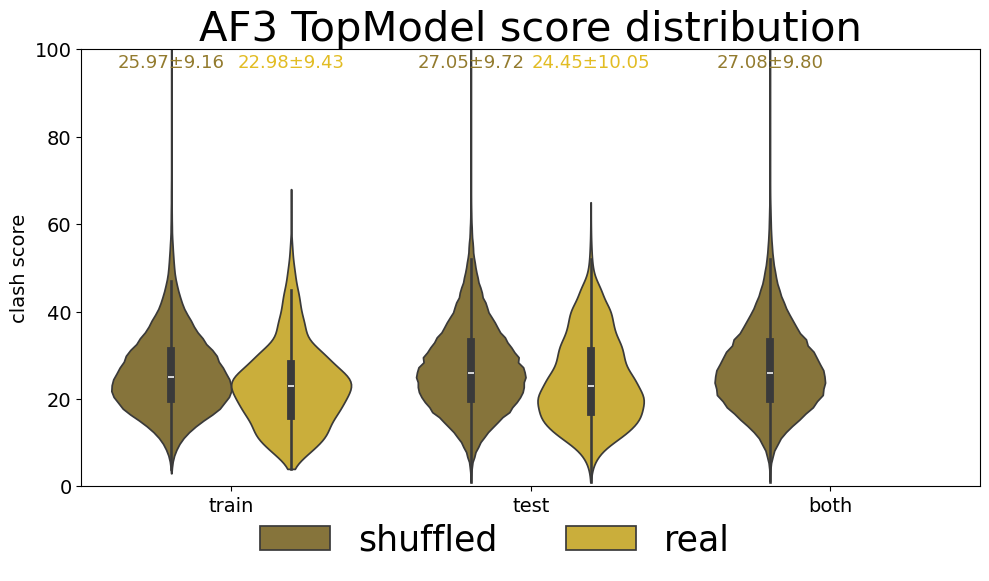

In [10]:
plot_split_distribution_df(
    df_af3,
    col="score",
    kind="violin",
    title="AF3 TopModel score distribution",
    palette=palette,
    x_order=("train", "test", "both"),
    ylim=(0, 100),   # or (0, 100) if your score is 0-100
    save_path=f"{image_path}af_3_structural_accuracy_topmodel_violin.png",
)
plt.show()

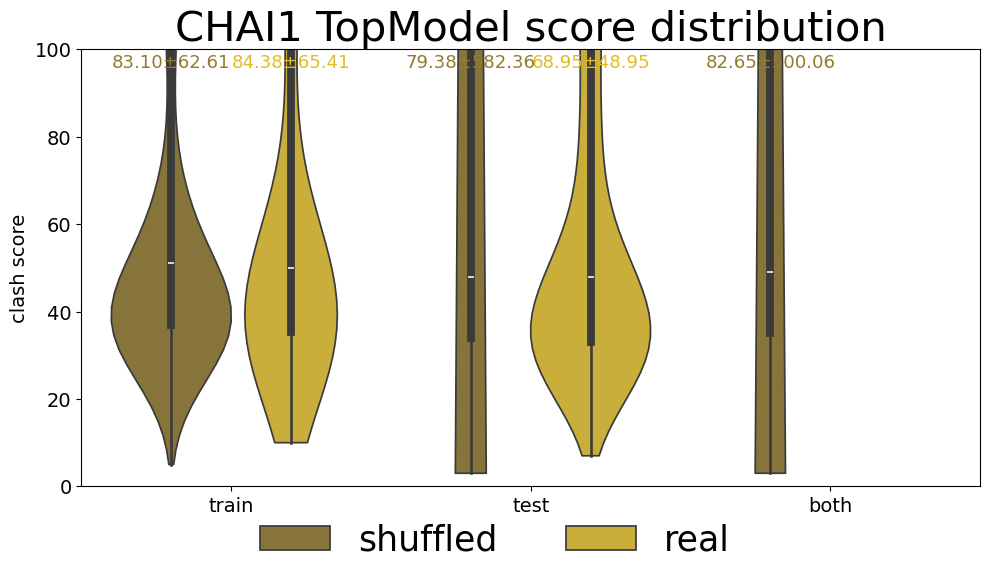

In [11]:
plot_split_distribution_df(
    df_chai1,
    col="score",
    kind="violin",
    title="CHAI1 TopModel score distribution",
    palette=palette,
    x_order=("train", "test", "both"),
    ylim=(0, 100),   # or (0, 100) if your score is 0-100
    save_path=f"{image_path}chai_1_structural_accuracy_topmodel_violin.png",
)
plt.show()

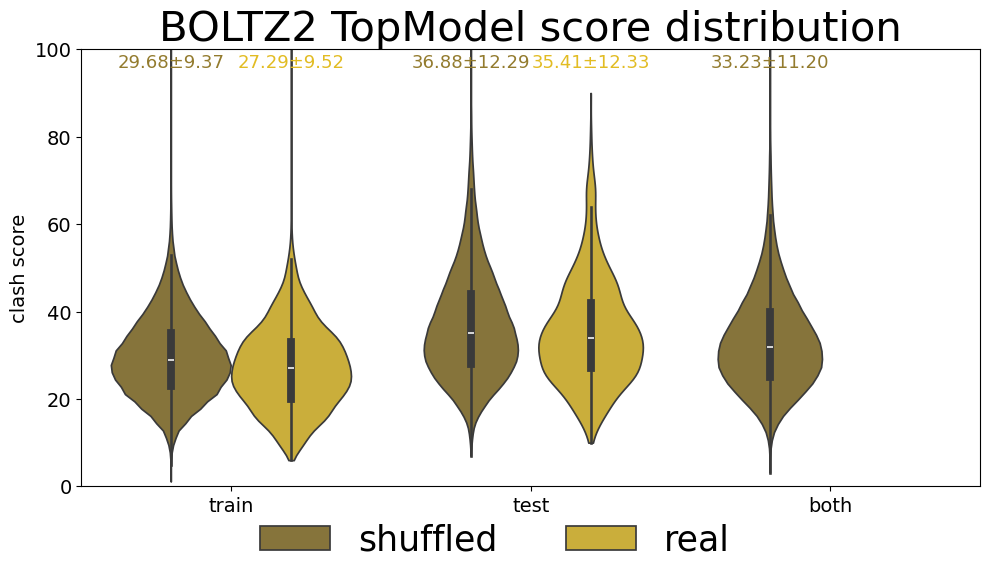

In [12]:
plot_split_distribution_df(
    df_boltz2,
    col="score",
    kind="violin",
    title="BOLTZ2 TopModel score distribution",
    palette=palette,
    x_order=("train", "test", "both"),
    ylim=(0, 100),   # or (0, 100) if your score is 0-100
    save_path=f"{image_path}boltz_2_structural_accuracy_topmodel_violin.png",
)
plt.show()